In [74]:
import numpy as np
import torch
from matplotlib import pyplot as plt
import torcwa
from tqdm.notebook import tqdm
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from Utils.utils import *

%load_ext line_profiler

# Hardware
# If GPU support TF32 tensor core, the matmul operation is faster than FP32 but with less precision.
# If you need accurate operation, you have to disable the flag below.
torch.backends.cuda.matmul.allow_tf32 = False
sim_dtype = torch.complex64
geo_dtype = torch.float32
device = torch.device('cuda')

# Simulation environment
# light
eps = 1e-3
inc_ang = (30+eps)*(np.pi/180)   # radian
azi_ang = (0+eps)*(np.pi/180)   # radian

order_N = 25

# geometry
h = 1000 #nm
grating_period = 1000 # nm
n = 5000

x_plot = torch.linspace(-grating_period/2,grating_period/2,501,device=device)
y_plot = torch.clone(x_plot)
z_plot = torch.linspace(-0.5*h,2*h,501,device=device)

wavelength = torch.tensor(700+1e-3)
wavelengths = torch.linspace(300, 1100, 1601, dtype=float)+1e-3 # for stability

#Sanity check of staircase approximation
num_layers = 100

config = RCWAConfig(grating_period=grating_period, grating_period_y=grating_period,h=h,order_N=order_N, order_N_y=order_N, \
    nx = n, ny = n, n_layers = num_layers, subpixel = False, add_reflector = True, reflector_type = 'pec', inc_ang = inc_ang, azi_ang = azi_ang,grating_material="Si")

params_x = torch.tensor([[500,0] for i in range(1)], dtype=geo_dtype, device=device)
#params_y = torch.tensor([[0., 0.]], dtype=geo_dtype, device=device)
#params_y = torch.tensor([[10,0] for i in range(10)], dtype=geo_dtype, device=device)
params_y = None

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


## Testing and plotting

In [75]:
wavelengths

tensor([ 300.0010,  300.5010,  301.0010,  ..., 1099.0010, 1099.5010,
        1100.0010], dtype=torch.float64)

In [76]:
sim, sine_eps, A_film, A_grating, Reflectance, Transmittance, P_abs_film, P_abs_grating \
    = get_absorptance(params_x,params_y,wavelength,config)

In [77]:
polarization = [1,0]

(<Figure size 500x800 with 2 Axes>,
 <Axes: title={'center': 'E norm'}, xlabel='x (nm)', ylabel='z (nm)'>)

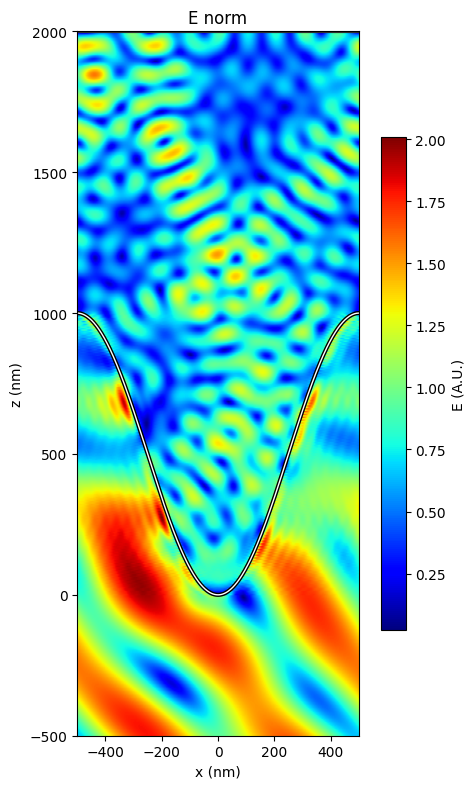

In [78]:
plot_fields(sim, x_plot, z_plot, wavelength, polarization, params_x, params_y, config, field="E norm", thickness=1,y_plot=y_plot, slice_plane='xz', slice_val=0)

In [79]:
A_film + A_grating + Reflectance + Transmittance

tensor([1.0000, 1.0000], device='cuda:0')

In [80]:
A_film, A_grating, Reflectance, Transmittance

(tensor([0.4282, 0.4037], device='cuda:0'),
 tensor([0.2351, 0.3182], device='cuda:0'),
 tensor([0.3367, 0.2780], device='cuda:0'),
 tensor([-6.4138e-09,  1.0642e-06], device='cuda:0'))

In [134]:
def objective_function(params):
    """
    Objective function to minimize: negative weighted absorptance.
    """
    transformed = torch.stack((torch.exp(params[:,0]), 2*torch.atan(params[:,1])), dim=-1)
    loss = torch.zeros(1).cuda()
    A_film, A_grating = \
        get_absorptance(transformed,None,wavelength,config)[2:4]
    loss += -A_film[0]-A_film[1]
    #print(A_film)
    return loss

In [140]:
#find optimal parameters
init_params_x = torch.tensor([[np.log(10),0] for i in range(10)],dtype=geo_dtype,device=device,requires_grad=True)
opt = torch.optim.AdamW([init_params_x], lr=1e-1,weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.99)

pbar = tqdm(range(500), desc="Optimizing Parameters")
best_loss = float('inf')

for it in pbar:
    opt.zero_grad()
    loss = objective_function(init_params_x)
    loss.backward()
    opt.step()
    scheduler.step()
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_params = init_params_x.detach().clone()
    pbar.set_description(f"Iteration {it}: Loss = {loss.item():.4f} - lr = {scheduler.get_last_lr()[0]:.4f}")

Iteration 499: Loss = -1.4210 - lr = 0.0007: 100%|██████████| 500/500 [06:46<00:00,  1.23it/s]


In [141]:
best_params

tensor([[ 2.4107,  0.7904],
        [ 2.8098,  2.4067],
        [ 3.2990, -0.4120],
        [ 3.3812, -0.3109],
        [ 1.5072, -2.7307],
        [ 3.1214,  0.9351],
        [ 0.6973, -2.0057],
        [ 0.7319,  1.0596],
        [ 2.0568, -1.2902],
        [ 0.9169,  2.0469]], device='cuda:0')

In [142]:
best_params = torch.stack((torch.exp(best_params[:,0]), 2*torch.atan(best_params[:,1])), dim=-1).detach()

In [143]:
best_params

tensor([[11.1418,  1.3377],
        [16.6073,  2.3540],
        [27.0843, -0.7817],
        [29.4074, -0.6029],
        [ 4.5139, -2.4395],
        [22.6775,  1.5038],
        [ 2.0083, -2.2166],
        [ 2.0790,  1.6286],
        [ 7.8211, -1.8229],
        [ 2.5016,  2.2327]], device='cuda:0')

In [147]:
sum(best_params[:,0])

tensor(125.8421, device='cuda:0')

In [144]:
sim, sine_eps, A_film, A_grating, Reflectance, Transmittance, P_abs_film, P_abs_grating \
    = get_absorptance(best_params,None,wavelength,config)

In [145]:
polarization = [1,0]

(<Figure size 500x800 with 2 Axes>,
 <Axes: title={'center': 'E norm'}, xlabel='x (nm)', ylabel='z (nm)'>)

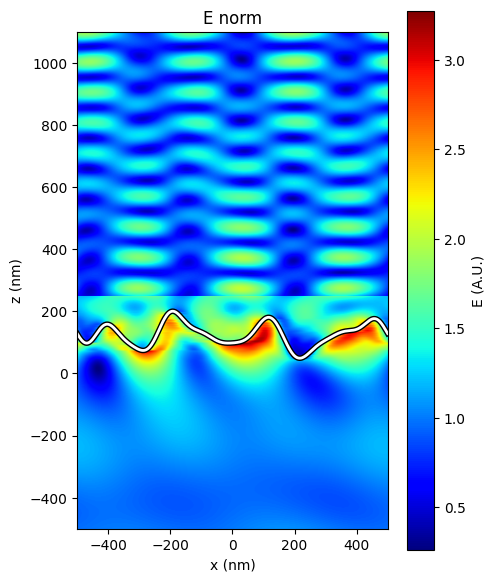

In [146]:
plot_fields(sim, x_plot, z_plot, wavelength, polarization, best_params,None, config, field="E norm", thickness=2,y_plot=y_plot, slice_plane='xz', slice_val=0)

In [121]:
A_film

tensor([0.0095, 0.0023], device='cuda:0')

## Absorptance curves

### Num layers

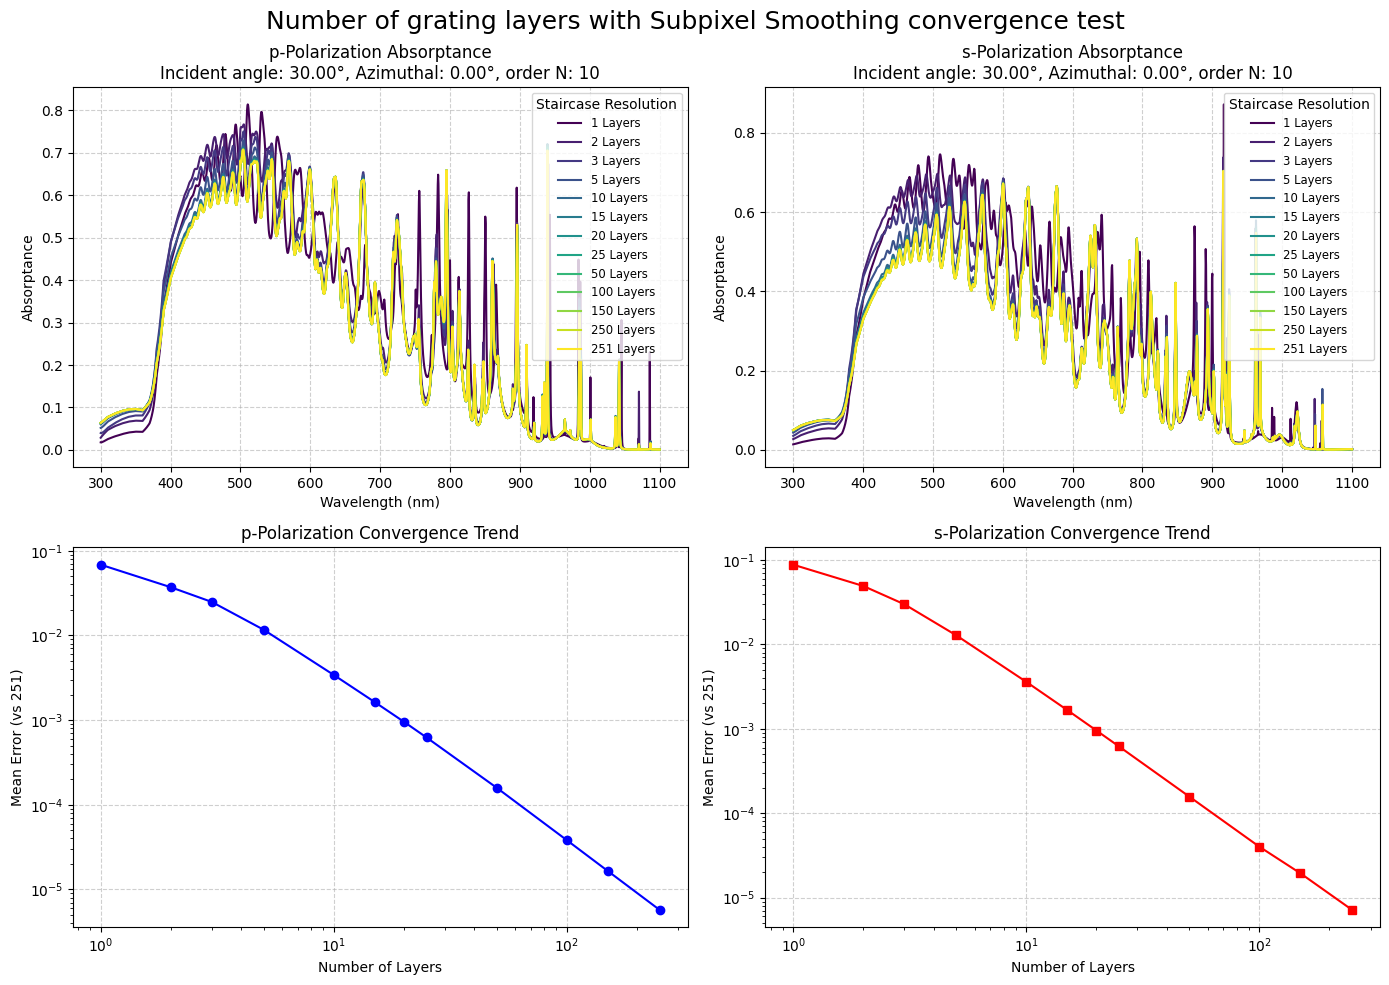

In [115]:
# Load the saved simulation data
saved_data = torch.load('../Data/AbsorptanceCurves/sweep_num_layers_2026-06-03.pt', weights_only=False)
results = saved_data['results']
metadata = saved_data['metadata']

wavelengths = metadata['wavelengths']
inc_ang = metadata['inc_ang_deg']
azi_ang = metadata['azi_ang_deg']

layer_counts = []
key_map = {}

for key in results.keys():
    num = int(key.split('_')[-1])
    order_N = int(key.split('_')[2])
    layer_counts.append(num)
    key_map[num] = key

layer_counts = sorted(layer_counts)
best_layer_count = layer_counts[-1]
best_abs = results[key_map[best_layer_count]]['A_film']

# Pre-calculate mean errors
mean_errors_p = []
mean_errors_s = []
plot_layers = []

for num_layers in layer_counts:
    if num_layers == best_layer_count:
        continue
    curr_abs = results[key_map[num_layers]]['A_film']
    
    # Use torch functions instead of np functions on tensors
    err_p = torch.mean(torch.abs((curr_abs[:, 0] - best_abs[:, 0]))).item()
    err_s = torch.mean(torch.abs((curr_abs[:, 1] - best_abs[:, 1]))).item()
    
    mean_errors_p.append(err_p)
    mean_errors_s.append(err_s)
    plot_layers.append(num_layers)

# Create a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
(ax1_p, ax1_s), (ax2_p, ax2_s) = axs

colors = plt.cm.viridis(np.linspace(0, 1, len(layer_counts)))

for idx, num_layers in enumerate(layer_counts):
    curr_abs = results[key_map[num_layers]]['A_film']
    
    # Top Row: Plot spectra
    ax1_p.plot(wavelengths.cpu(), curr_abs[:, 0].cpu(), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5)
    ax1_s.plot(wavelengths.cpu(), curr_abs[:, 1].cpu(), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5)
# Format Top Row (Absorptance Spectra)
ax1_p.set_xlabel('Wavelength (nm)')
ax1_p.set_ylabel('Absorptance')
ax1_p.set_title(f'p-Polarization Absorptance\nIncident angle: {inc_ang:.2f}°, Azimuthal: {azi_ang:.2f}°, order N: {order_N}')
ax1_p.grid(True, linestyle='--', alpha=0.6)
ax1_p.legend(title='Staircase Resolution', loc='best', fontsize='small')
#ax1_p.set_yscale('log')

ax1_s.set_xlabel('Wavelength (nm)')
ax1_s.set_ylabel('Absorptance')
ax1_s.set_title(f's-Polarization Absorptance\nIncident angle: {inc_ang:.2f}°, Azimuthal: {azi_ang:.2f}°, order N: {order_N}')
ax1_s.grid(True, linestyle='--', alpha=0.6)
ax1_s.legend(title='Staircase Resolution', loc='best', fontsize='small')
#ax1_s.set_yscale('log')

# Format Bottom Row (Mean Error Convergence)
ax2_p.plot(plot_layers, mean_errors_p, marker='o', linestyle='-', color='blue')
ax2_p.set_xlabel('Number of Layers')
ax2_p.set_ylabel(f'Mean Error (vs {best_layer_count})')
ax2_p.set_title('p-Polarization Convergence Trend')
ax2_p.grid(True, linestyle='--', alpha=0.6)
ax2_p.set_yscale('log')
ax2_p.set_xscale('log')

ax2_s.plot(plot_layers, mean_errors_s, marker='s', linestyle='-', color='red')
ax2_s.set_xlabel('Number of Layers')
ax2_s.set_ylabel(f'Mean Error (vs {best_layer_count})')         
ax2_s.set_title('s-Polarization Convergence Trend')
ax2_s.grid(True, linestyle='--', alpha=0.6)
ax2_s.set_yscale('log')
ax2_s.set_xscale('log')

fig.suptitle('Number of grating layers with Subpixel Smoothing convergence test',fontsize=18)
fig.tight_layout()
fig.savefig('../Data/Num_layer_convergence_fig')
plt.show()

In [15]:
# Load the saved simulation data
results = torch.load('../Data/rcwa_convergence_data_num_layers_no_smoothing.pt', weights_only=False)
layer_counts = sorted(list(results.keys()))

best_layer_count = layer_counts[-1]
best_abs = results[best_layer_count]['absorptances_film']

# Pre-calculate mean errors
mean_errors_p = []
mean_errors_s = []
plot_layers = []

for num_layers in layer_counts:
    if num_layers == best_layer_count:
        continue
    curr_abs = results[num_layers]['absorptances_film']
    
    # Use torch functions instead of np functions on tensors
    err_p = torch.mean(torch.abs((curr_abs[:, 0] - best_abs[:, 0]))).item()
    err_s = torch.mean(torch.abs((curr_abs[:, 1] - best_abs[:, 1]))).item()
    
    mean_errors_p.append(err_p)
    mean_errors_s.append(err_s)
    plot_layers.append(num_layers)

# Create a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
(ax1_p, ax1_s), (ax2_p, ax2_s) = axs

colors = plt.cm.viridis(np.linspace(0, 1, len(layer_counts)))

for idx, num_layers in enumerate(layer_counts):
    curr_abs = results[num_layers]['absorptances_film']
    
    # Top Row: Plot spectra
    ax1_p.plot(wavelengths.cpu(), curr_abs[:, 0].cpu(), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5)
    ax1_s.plot(wavelengths.cpu(), curr_abs[:, 1].cpu(), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5)
# Format Top Row (Absorptance Spectra)
ax1_p.set_xlabel('Wavelength (nm)')
ax1_p.set_ylabel('Absorptance')
ax1_p.set_title(f'p-Polarization Absorptance\nIncident angle: {inc_ang*180/np.pi:.2f}°, Azimuthal: {azi_ang*180/np.pi:.2f}°')
ax1_p.grid(True, linestyle='--', alpha=0.6)
ax1_p.legend(title='Staircase Resolution', loc='best', fontsize='small')
#ax1_p.set_yscale('log')

ax1_s.set_xlabel('Wavelength (nm)')
ax1_s.set_ylabel('Absorptance')
ax1_s.set_title(f's-Polarization Absorptance\nIncident angle: {inc_ang*180/np.pi:.2f}°, Azimuthal: {azi_ang*180/np.pi:.2f}°')
ax1_s.grid(True, linestyle='--', alpha=0.6)
ax1_s.legend(title='Staircase Resolution', loc='best', fontsize='small')
#ax1_s.set_yscale('log')

# Format Bottom Row (Mean Error Convergence)
ax2_p.plot(plot_layers, mean_errors_p, marker='o', linestyle='-', color='blue')
ax2_p.set_xlabel('Number of Layers')
ax2_p.set_ylabel(f'Mean Error (vs {best_layer_count})')
ax2_p.set_title('p-Polarization Convergence Trend')
ax2_p.grid(True, linestyle='--', alpha=0.6)
ax2_p.set_yscale('log')
ax2_p.set_xscale('log')

ax2_s.plot(plot_layers, mean_errors_s, marker='s', linestyle='-', color='red')
ax2_s.set_xlabel('Number of Layers')
ax2_s.set_ylabel(f'Mean Error (vs {best_layer_count})')
ax2_s.set_title('s-Polarization Convergence Trend')
ax2_s.grid(True, linestyle='--', alpha=0.6)
ax2_s.set_yscale('log')
ax2_s.set_xscale('log')

fig.suptitle('No Smoothing')
fig.tight_layout()
fig.savefig('../Data/Num_layer_convergence_fig_no_smoothing')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../Data/rcwa_convergence_data_num_layers_no_smoothing.pt'

In [16]:
# Load both saved simulation datasets
results_no = torch.load('../Data/rcwa_convergence_data_num_layers_no_smoothing.pt', weights_only=False)
results_sm = torch.load('../Data/rcwa_convergence_data_num_layers.pt', weights_only=False)

layer_counts = sorted(list(results_no.keys()))
best_layer_count = layer_counts[-1]

# Baselines for each dataset
best_abs_no = results_no[best_layer_count]['absorptances_film']
best_abs_sm = results_sm[best_layer_count]['absorptances_film']

# Pre-calculate mean errors
mean_errors_p_no, mean_errors_s_no = [], []
mean_errors_p_sm, mean_errors_s_sm = [], []
plot_layers = []

for num_layers in layer_counts:
    if num_layers == best_layer_count:
        continue
    plot_layers.append(num_layers)
    
    # Calculate No Smoothing errors
    curr_abs_no = results_no[num_layers]['absorptances_film']
    mean_errors_p_no.append(torch.mean(torch.abs((curr_abs_no[:, 0] - best_abs_no[:, 0]))).item())
    mean_errors_s_no.append(torch.mean(torch.abs((curr_abs_no[:, 1] - best_abs_no[:, 1]))).item())
    
    # Calculate Smoothing errors
    curr_abs_sm = results_sm[num_layers]['absorptances_film']
    mean_errors_p_sm.append(torch.mean(torch.abs((curr_abs_sm[:, 0] - best_abs_sm[:, 0]))).item())
    mean_errors_s_sm.append(torch.mean(torch.abs((curr_abs_sm[:, 1] - best_abs_sm[:, 1]))).item())

# Create a 3x2 grid
fig, axs = plt.subplots(3, 2, figsize=(14, 15))
(ax1_p, ax1_s), (ax2_p, ax2_s), (ax3_p, ax3_s) = axs

colors = plt.cm.viridis(np.linspace(0, 1, len(layer_counts)))

for idx, num_layers in enumerate(layer_counts):
    curr_abs_no = results_no[num_layers]['absorptances_film']
    curr_abs_sm = results_sm[num_layers]['absorptances_film']
    
    # Row 1: Plot spectra (No Smoothing)
    ax1_p.plot(wavelengths.cpu(), curr_abs_no[:, 0].cpu(), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5)
    ax1_s.plot(wavelengths.cpu(), curr_abs_no[:, 1].cpu(), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5)
    
    # Row 2: Plot spectra (With Smoothing)
    ax2_p.plot(wavelengths.cpu(), curr_abs_sm[:, 0].cpu(), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5)
    ax2_s.plot(wavelengths.cpu(), curr_abs_sm[:, 1].cpu(), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5)

# --- Format Row 1 (No Smoothing Spectra) ---
ax1_p.set_xlabel('Wavelength (nm)')
ax1_p.set_ylabel('Absorptance')
ax1_p.set_title(f'p-Polarization Spectra (No Smoothing)\nIncident angle: {inc_ang*180/np.pi:.2f}°, Azimuthal: {azi_ang*180/np.pi:.2f}°')
ax1_p.grid(True, linestyle='--', alpha=0.6)
ax1_p.legend(title='Staircase Resolution', loc='best', fontsize='small')

ax1_s.set_xlabel('Wavelength (nm)')
ax1_s.set_ylabel('Absorptance')
ax1_s.set_title(f's-Polarization Spectra (No Smoothing)\nIncident angle: {inc_ang*180/np.pi:.2f}°, Azimuthal: {azi_ang*180/np.pi:.2f}°')
ax1_s.grid(True, linestyle='--', alpha=0.6)
ax1_s.legend(title='Staircase Resolution', loc='best', fontsize='small')

# --- Format Row 2 (With Smoothing Spectra) ---
ax2_p.set_xlabel('Wavelength (nm)')
ax2_p.set_ylabel('Absorptance')
ax2_p.set_title('p-Polarization Spectra (With Smoothing)')
ax2_p.grid(True, linestyle='--', alpha=0.6)
ax2_p.legend(title='Staircase Resolution', loc='best', fontsize='small')

ax2_s.set_xlabel('Wavelength (nm)')
ax2_s.set_ylabel('Absorptance')
ax2_s.set_title('s-Polarization Spectra (With Smoothing)')
ax2_s.grid(True, linestyle='--', alpha=0.6)
ax2_s.legend(title='Staircase Resolution', loc='best', fontsize='small')

# --- Format Row 3 (Mean Error Convergence Comparison) ---
# p-polarization
ax3_p.plot(plot_layers, mean_errors_p_no, marker='o', linestyle='-', color='blue', label='No Smoothing')
ax3_p.plot(plot_layers, mean_errors_p_sm, marker='^', linestyle='--', color='dodgerblue', label='With Smoothing')
ax3_p.set_xlabel('Number of Layers')
ax3_p.set_ylabel(f'Mean Error (vs {best_layer_count})')
ax3_p.set_title('p-Polarization Convergence Trend')
ax3_p.grid(True, linestyle='--', alpha=0.6)
ax3_p.set_yscale('log')
ax3_p.set_xscale('log')
ax3_p.legend()

# s-polarization
ax3_s.plot(plot_layers, mean_errors_s_no, marker='s', linestyle='-', color='red', label='No Smoothing')
ax3_s.plot(plot_layers, mean_errors_s_sm, marker='^', linestyle='--', color='darkorange', label='With Smoothing')
ax3_s.set_xlabel('Number of Layers')
ax3_s.set_ylabel(f'Mean Error (vs {best_layer_count})')
ax3_s.set_title('s-Polarization Convergence Trend')
ax3_s.grid(True, linestyle='--', alpha=0.6)
ax3_s.set_yscale('log')
ax3_s.set_xscale('log')
ax3_s.legend()

fig.suptitle('RCWA Convergence: Smoothing vs No Smoothing', fontsize=18)
fig.tight_layout()
fig.savefig('../Data/Num_layer_convergence_3x2_comparison.png')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../Data/rcwa_convergence_data_num_layers_no_smoothing.pt'

#### compare to comsol

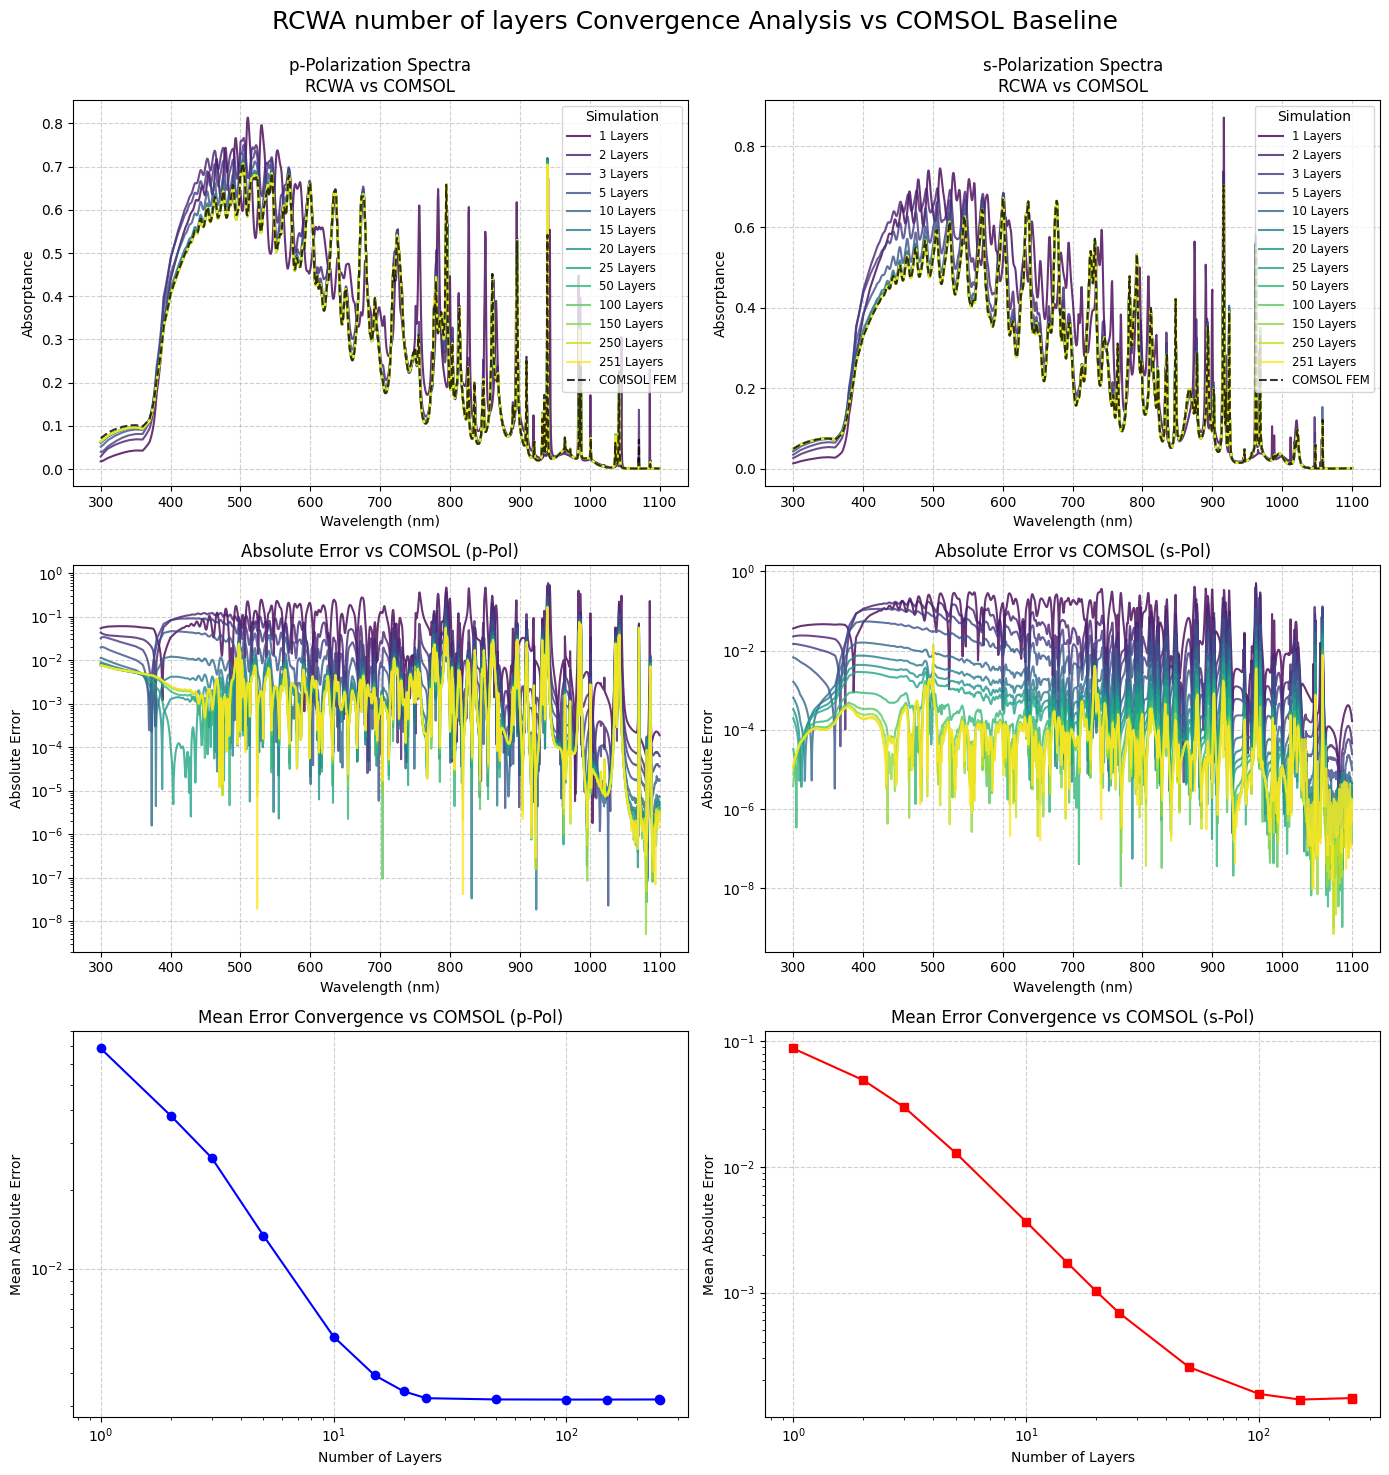

In [17]:
# ---------------------------------------------------------
# 1. Load the Data
# ---------------------------------------------------------
# Load RCWA Data
saved_data = torch.load('../Data/AbsorptanceCurves/sweep_num_layers_2026-06-03.pt', weights_only=False)
results = saved_data['results']
metadata = saved_data['metadata']

wavelengths = metadata['wavelengths'].cpu().numpy()
inc_ang = metadata['inc_ang_deg']
azi_ang = metadata['azi_ang_deg']

layer_counts = []
key_map = {}
for key in results.keys():
    num = int(key.split('_')[-1])
    layer_counts.append(num)
    key_map[num] = key

layer_counts = sorted(layer_counts)
best_layer_count = layer_counts[-1]

# Load COMSOL Data
# IMPORTANT: Update the p-pol filepath to match your actual COMSOL export file
comsol_data_s = np.loadtxt('/home/an/Documents/COMSOL/mph files/light_trapping_layer/outputs/Absorptance_curve_with_IBC_spol.txt', comments='%')
comsol_data_p = np.loadtxt('/home/an/Documents/COMSOL/mph files/light_trapping_layer/outputs/Absorptance_curve_with_IBC_ppol.txt', comments='%')

comsol_wavelengths = comsol_data_s[:, 0]
comsol_abs_s = comsol_data_s[:, 4]
comsol_abs_p = comsol_data_p[:, 2]

# ---------------------------------------------------------
# 2. Pre-calculate Mean Errors vs COMSOL
# ---------------------------------------------------------
mean_errors_p_vs_comsol = []
mean_errors_s_vs_comsol = []

for num_layers in layer_counts:
    curr_abs = results[key_map[num_layers]]['A_film'].cpu().numpy()
    
    # Direct subtraction relies on matching wavelength grids
    err_p = np.mean(np.abs(curr_abs[:, 0] - comsol_abs_p))
    err_s = np.mean(np.abs(curr_abs[:, 1] - comsol_abs_s))
    
    mean_errors_p_vs_comsol.append(err_p)
    mean_errors_s_vs_comsol.append(err_s)

# ---------------------------------------------------------
# 3. Create the 3x2 Plot
# ---------------------------------------------------------
fig, axs = plt.subplots(3, 2, figsize=(14, 15))
(ax1_p, ax1_s), (ax2_p, ax2_s), (ax3_p, ax3_s) = axs

colors = plt.cm.viridis(np.linspace(0, 1, len(layer_counts)))

for idx, num_layers in enumerate(layer_counts):
    curr_abs = results[key_map[num_layers]]['A_film'].cpu().numpy()
    rcwa_p = curr_abs[:, 0]
    rcwa_s = curr_abs[:, 1]
    
    # --- Row 1: Absorptance Spectra ---
    ax1_p.plot(wavelengths, rcwa_p, label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5, alpha=0.8)
    ax1_s.plot(wavelengths, rcwa_s, label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5, alpha=0.8)
    
    # --- Row 2: Error Spectra vs COMSOL ---
    ax2_p.plot(wavelengths, np.abs(comsol_abs_p - rcwa_p), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5, alpha=0.8)
    ax2_s.plot(wavelengths, np.abs(comsol_abs_s - rcwa_s), label=f'{num_layers} Layers', color=colors[idx], linewidth=1.5, alpha=0.8)

# --- Overlay COMSOL Baselines & Zero Lines ---
# Row 1 Baselines
ax1_p.plot(comsol_wavelengths, comsol_abs_p, label='COMSOL FEM', color='black', alpha=0.8, linestyle='--', linewidth=1.5)
ax1_s.plot(comsol_wavelengths, comsol_abs_s, label='COMSOL FEM', color='black', alpha=0.8, linestyle='--', linewidth=1.5)

# Row 2 Zero Lines (Ideal Error)
ax2_p.axhline(0, color='black', alpha=0.8, linestyle='--', linewidth=1.5, label='Zero Error')
ax2_s.axhline(0, color='black', alpha=0.8, linestyle='--', linewidth=1.5, label='Zero Error')

# --- Formatting Row 1 (Spectra) ---
ax1_p.set_title(f'p-Polarization Spectra\nRCWA vs COMSOL')
ax1_p.set_ylabel('Absorptance')
ax1_p.grid(True, linestyle='--', alpha=0.6)
ax1_p.legend(title='Simulation', loc='best', fontsize='small')

ax1_s.set_title(f's-Polarization Spectra\nRCWA vs COMSOL')
ax1_s.set_ylabel('Absorptance')
ax1_s.grid(True, linestyle='--', alpha=0.6)
ax1_s.legend(title='Simulation', loc='best', fontsize='small')

# --- Formatting Row 2 (Error Spectra) ---
ax2_p.set_title('Absolute Error vs COMSOL (p-Pol)')
ax2_p.set_ylabel('Absolute Error')
ax2_p.set_yscale('log')
ax2_p.grid(True, linestyle='--', alpha=0.6)

ax2_s.set_title('Absolute Error vs COMSOL (s-Pol)')
ax2_s.set_ylabel('Absolute Error')
ax2_s.set_yscale('log')
ax2_s.grid(True, linestyle='--', alpha=0.6)

# --- Formatting Row 3 (Convergence Trend) ---
ax3_p.plot(layer_counts, mean_errors_p_vs_comsol, marker='o', linestyle='-', color='blue')
ax3_p.set_title('Mean Error Convergence vs COMSOL (p-Pol)')
ax3_p.set_xlabel('Number of Layers')
ax3_p.set_ylabel('Mean Absolute Error')
ax3_p.set_xscale('log')
ax3_p.set_yscale('log')
ax3_p.grid(True, linestyle='--', alpha=0.6)

ax3_s.plot(layer_counts, mean_errors_s_vs_comsol, marker='s', linestyle='-', color='red')
ax3_s.set_title('Mean Error Convergence vs COMSOL (s-Pol)')
ax3_s.set_xlabel('Number of Layers')
ax3_s.set_ylabel('Mean Absolute Error')
ax3_s.set_xscale('log')
ax3_s.set_yscale('log')
ax3_s.grid(True, linestyle='--', alpha=0.6)

# Provide bottom x-labels for the columns
for ax in [ax1_p, ax1_s, ax2_p, ax2_s]:
    ax.set_xlabel('Wavelength (nm)')

fig.suptitle('RCWA number of layers Convergence Analysis vs COMSOL Baseline', fontsize=18)
fig.tight_layout()
fig.subplots_adjust(top=0.92)  # Adjust top spacing for the suptitle
fig.savefig('../Data/RCWA_vs_COMSOL_Full_Comparison_num_layers.png')
plt.show()

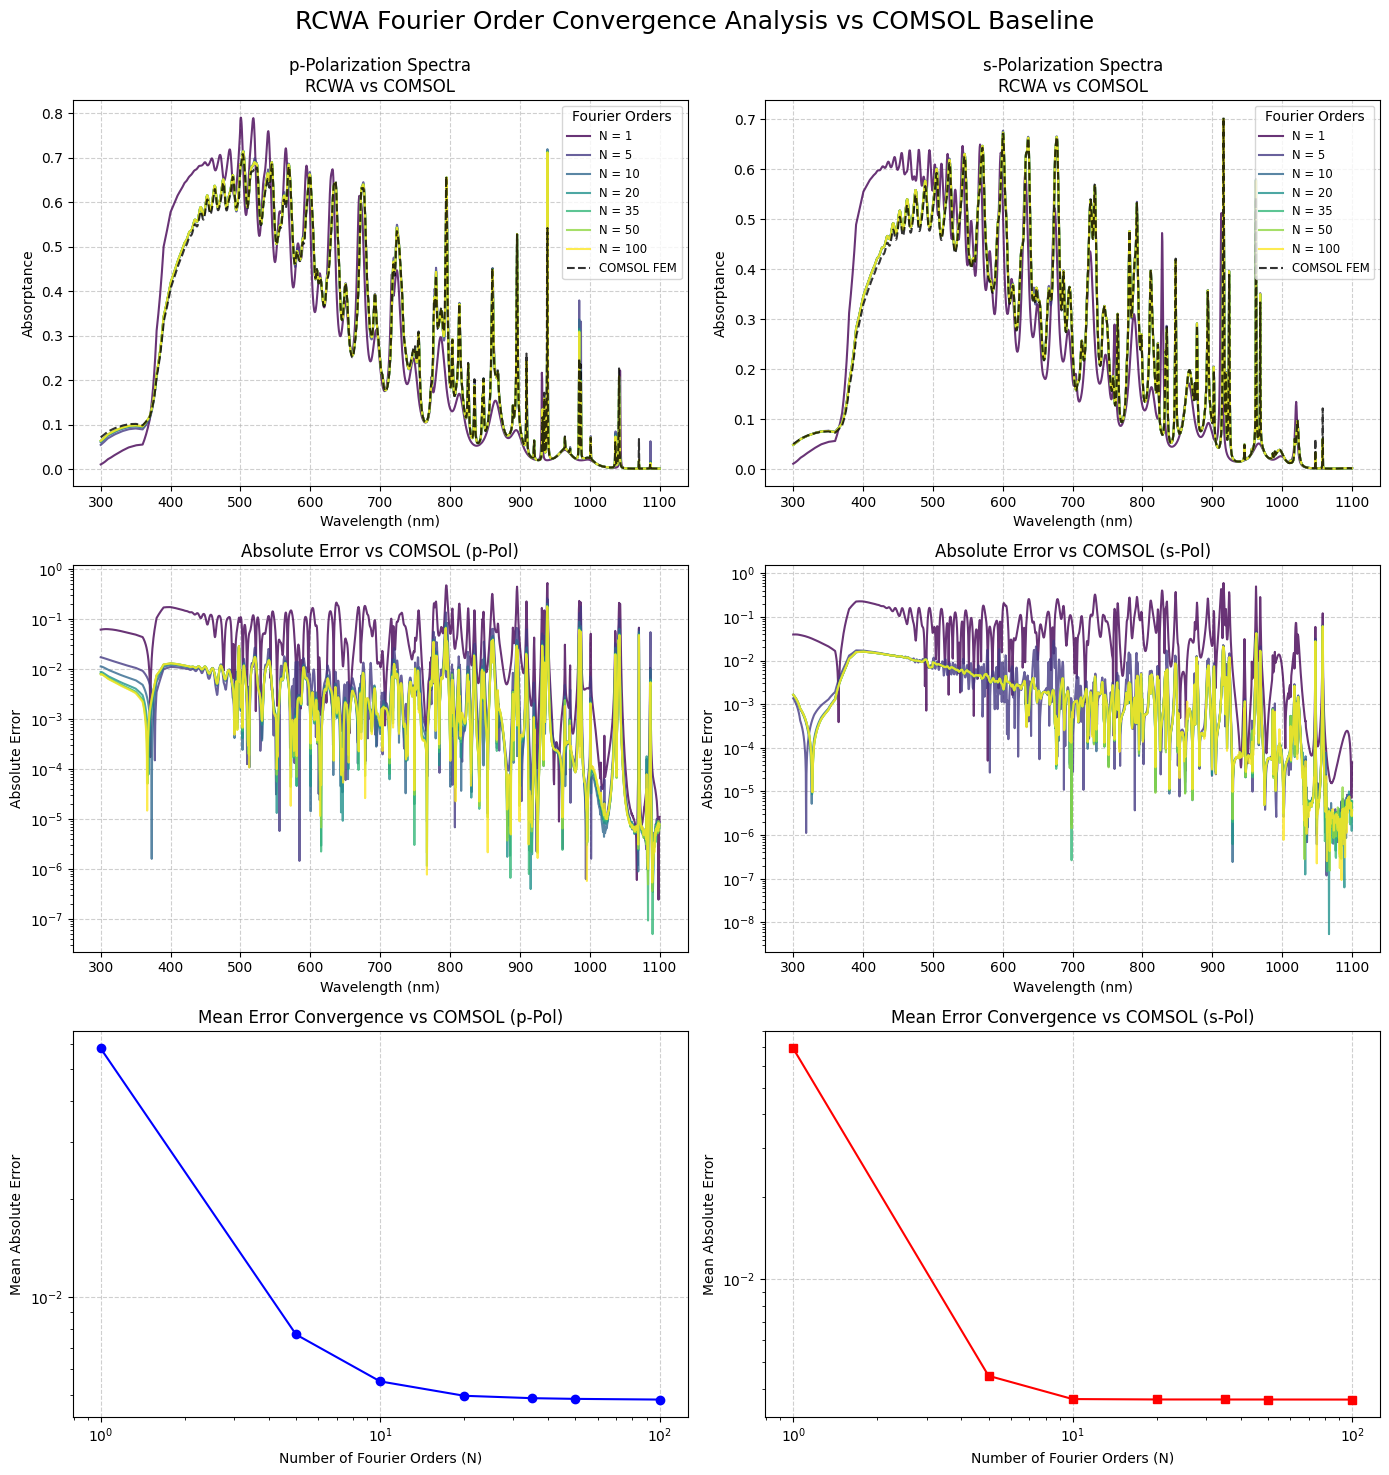

In [18]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Load the Data
# ---------------------------------------------------------
# Load RCWA Data
saved_data = torch.load('../Data/AbsorptanceCurves/sweep_order_N_2026-06-03.pt', weights_only=False)
results = saved_data['results']
metadata = saved_data['metadata']

wavelengths = metadata['wavelengths'].cpu().numpy()
inc_ang = metadata['inc_ang_deg']
azi_ang = metadata['azi_ang_deg']

order_Ns = []
key_map = {}
for key in results.keys():
    num = int(key.split('_')[2])
    order_Ns.append(num)
    key_map[num] = key

order_Ns = sorted(order_Ns)
best_order = order_Ns[-1]

# Load COMSOL Data
comsol_data_s = np.loadtxt('/home/an/Documents/COMSOL/mph files/light_trapping_layer/outputs/Absorptance_curve_with_IBC_spol.txt', comments='%')
comsol_data_p = np.loadtxt('/home/an/Documents/COMSOL/mph files/light_trapping_layer/outputs/Absorptance_curve_with_IBC_ppol.txt', comments='%')

comsol_wavelengths = comsol_data_s[:, 0]
comsol_abs_s = comsol_data_s[:, 4]
comsol_abs_p = comsol_data_p[:, 2]

# ---------------------------------------------------------
# 2. Pre-calculate Mean Errors vs COMSOL
# ---------------------------------------------------------
mean_errors_p_vs_comsol = []
mean_errors_s_vs_comsol = []

for order_N in order_Ns:
    curr_abs = results[key_map[order_N]]['A_film'].cpu().numpy()
    
    # Direct subtraction relies on matching wavelength grids
    err_p = np.mean(np.abs(curr_abs[:, 0] - comsol_abs_p))
    err_s = np.mean(np.abs(curr_abs[:, 1] - comsol_abs_s))
    
    mean_errors_p_vs_comsol.append(err_p)
    mean_errors_s_vs_comsol.append(err_s)

# ---------------------------------------------------------
# 3. Create the 3x2 Plot
# ---------------------------------------------------------
fig, axs = plt.subplots(3, 2, figsize=(14, 15))
(ax1_p, ax1_s), (ax2_p, ax2_s), (ax3_p, ax3_s) = axs

colors = plt.cm.viridis(np.linspace(0, 1, len(order_Ns)))

for idx, order_N in enumerate(order_Ns):
    curr_abs = results[key_map[order_N]]['A_film'].cpu().numpy()
    rcwa_p = curr_abs[:, 0]
    rcwa_s = curr_abs[:, 1]
    
    # --- Row 1: Absorptance Spectra ---
    ax1_p.plot(wavelengths, rcwa_p, label=f'N = {order_N}', color=colors[idx], linewidth=1.5, alpha=0.8)
    ax1_s.plot(wavelengths, rcwa_s, label=f'N = {order_N}', color=colors[idx], linewidth=1.5, alpha=0.8)
    
    # --- Row 2: Error Spectra vs COMSOL ---
    ax2_p.plot(wavelengths, np.abs(comsol_abs_p - rcwa_p), label=f'N = {order_N}', color=colors[idx], linewidth=1.5, alpha=0.8)
    ax2_s.plot(wavelengths, np.abs(comsol_abs_s - rcwa_s), label=f'N = {order_N}', color=colors[idx], linewidth=1.5, alpha=0.8)

# --- Overlay COMSOL Baselines & Zero Lines ---
# Row 1 Baselines
ax1_p.plot(comsol_wavelengths, comsol_abs_p, label='COMSOL FEM', color='black', alpha=0.8, linestyle='--', linewidth=1.5)
ax1_s.plot(comsol_wavelengths, comsol_abs_s, label='COMSOL FEM', color='black', alpha=0.8, linestyle='--', linewidth=1.5)

# Row 2 Zero Lines (Ideal Error)
ax2_p.axhline(0, color='black', alpha=0.8, linestyle='--', linewidth=1.5, label='Zero Error')
ax2_s.axhline(0, color='black', alpha=0.8, linestyle='--', linewidth=1.5, label='Zero Error')

# --- Formatting Row 1 (Spectra) ---
ax1_p.set_title(f'p-Polarization Spectra\nRCWA vs COMSOL')
ax1_p.set_ylabel('Absorptance')
ax1_p.grid(True, linestyle='--', alpha=0.6)
ax1_p.legend(title='Fourier Orders', loc='best', fontsize='small')

ax1_s.set_title(f's-Polarization Spectra\nRCWA vs COMSOL')
ax1_s.set_ylabel('Absorptance')
ax1_s.grid(True, linestyle='--', alpha=0.6)
ax1_s.legend(title='Fourier Orders', loc='best', fontsize='small')

# --- Formatting Row 2 (Error Spectra) ---
ax2_p.set_title('Absolute Error vs COMSOL (p-Pol)')
ax2_p.set_ylabel('Absolute Error')
ax2_p.set_yscale('log')
ax2_p.grid(True, linestyle='--', alpha=0.6)

ax2_s.set_title('Absolute Error vs COMSOL (s-Pol)')
ax2_s.set_ylabel('Absolute Error')
ax2_s.set_yscale('log')
ax2_s.grid(True, linestyle='--', alpha=0.6)

# --- Formatting Row 3 (Convergence Trend) ---
ax3_p.plot(order_Ns, mean_errors_p_vs_comsol, marker='o', linestyle='-', color='blue')
ax3_p.set_title('Mean Error Convergence vs COMSOL (p-Pol)')
ax3_p.set_xlabel('Number of Fourier Orders (N)')
ax3_p.set_ylabel('Mean Absolute Error')
ax3_p.set_xscale('log')
ax3_p.set_yscale('log')
ax3_p.grid(True, linestyle='--', alpha=0.6)

ax3_s.plot(order_Ns, mean_errors_s_vs_comsol, marker='s', linestyle='-', color='red')
ax3_s.set_title('Mean Error Convergence vs COMSOL (s-Pol)')
ax3_s.set_xlabel('Number of Fourier Orders (N)')
ax3_s.set_ylabel('Mean Absolute Error')
ax3_s.set_xscale('log')
ax3_s.set_yscale('log')
ax3_s.grid(True, linestyle='--', alpha=0.6)

# Provide bottom x-labels for the columns
for ax in [ax1_p, ax1_s, ax2_p, ax2_s]:
    ax.set_xlabel('Wavelength (nm)')

fig.suptitle('RCWA Fourier Order Convergence Analysis vs COMSOL Baseline', fontsize=18)
fig.tight_layout()
fig.subplots_adjust(top=0.92)  # Adjust top spacing for the suptitle
fig.savefig('../Data/RCWA_vs_COMSOL_Order_N_Full_Comparison.png')
plt.show()

### *Fourier* Order

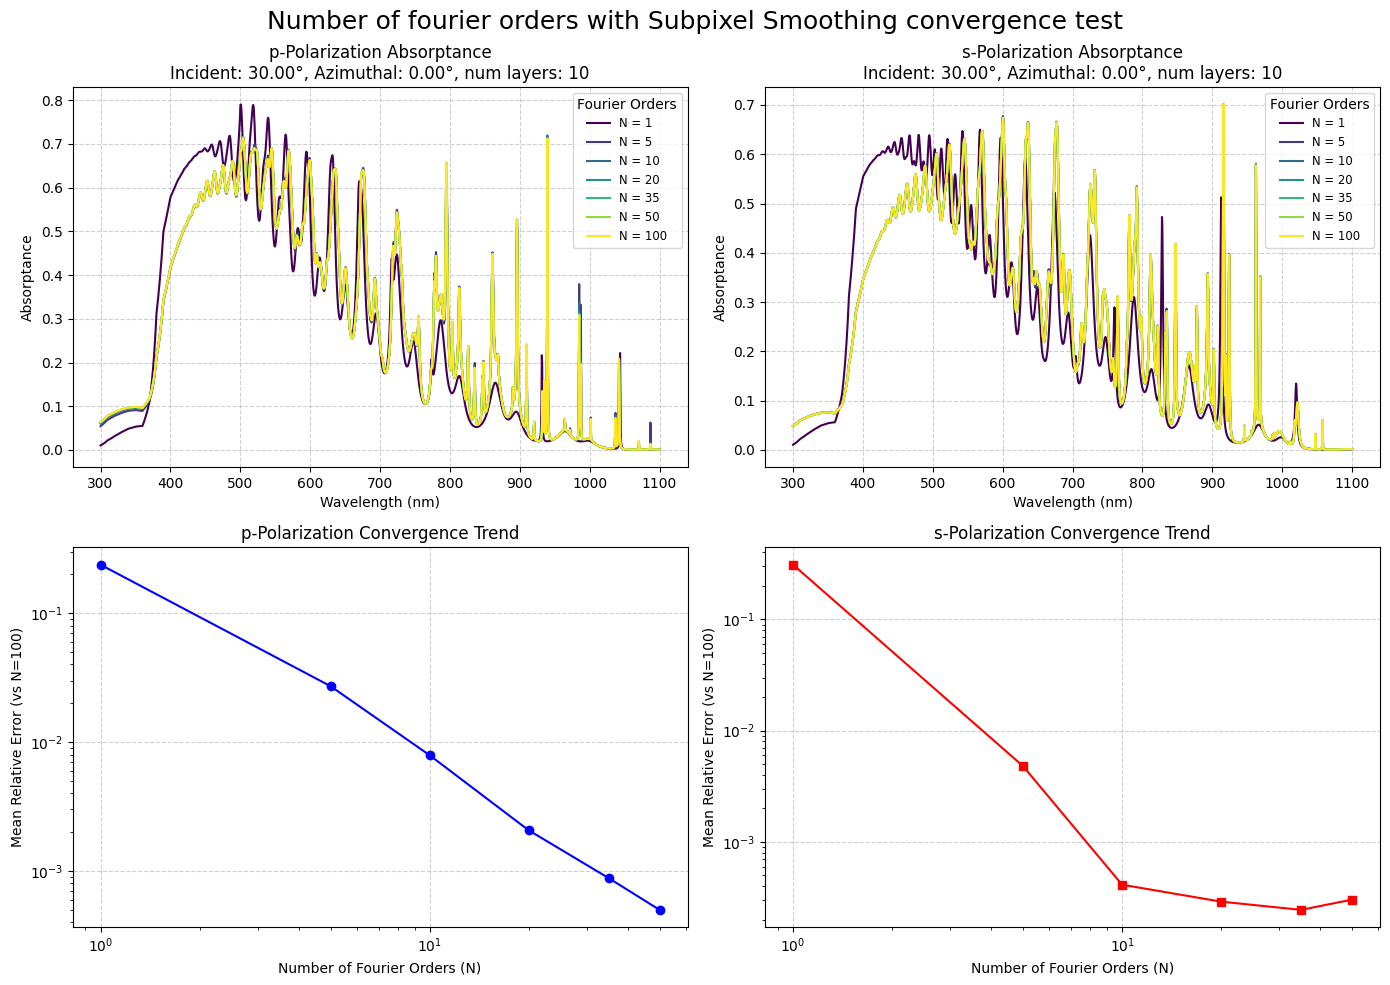

In [19]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Load the saved simulation data
saved_data = torch.load('../Data/AbsorptanceCurves/sweep_order_N_2026-06-03.pt', weights_only=False)
results = saved_data['results']
metadata = saved_data['metadata']

wavelengths = metadata['wavelengths']
inc_ang = metadata['inc_ang_deg']
azi_ang = metadata['azi_ang_deg']

# Create the key map for order_N
order_Ns = []
key_map = {}

for key in results.keys():
    # Extracts the integer value from keys like 'order_10' or 'sweep_10'
    num = int(key.split('_')[2])
    order_Ns.append(num)
    num_layers = int(key.split('_')[-1])
    key_map[num] = key

order_Ns = sorted(order_Ns)
best_order = order_Ns[-1]
best_abs = results[key_map[best_order]]['A_film']

# Pre-calculate mean relative errors
mean_errors_p = []
mean_errors_s = []
plot_orders = []

for order_N in order_Ns:
    if order_N == best_order:
        continue
    curr_abs = results[key_map[order_N]]['A_film']
    
    # Calculate relative error to the highest Fourier order
    err_p = torch.mean(torch.abs((curr_abs[:, 0] - best_abs[:, 0]) / (best_abs[:, 0] + 1e-12))).item()
    err_s = torch.mean(torch.abs((curr_abs[:, 1] - best_abs[:, 1]) / (best_abs[:, 1] + 1e-12))).item()
    
    mean_errors_p.append(err_p)
    mean_errors_s.append(err_s)
    plot_orders.append(order_N)

# Create a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
(ax1_p, ax1_s), (ax2_p, ax2_s) = axs

colors = plt.cm.viridis(np.linspace(0, 1, len(order_Ns)))

for idx, order_N in enumerate(order_Ns):
    curr_abs = results[key_map[order_N]]['A_film']
    
    # Top Row: Plot spectra
    ax1_p.plot(wavelengths.cpu(), curr_abs[:, 0].cpu(), label=f'N = {order_N}', color=colors[idx], linewidth=1.5)
    ax1_s.plot(wavelengths.cpu(), curr_abs[:, 1].cpu(), label=f'N = {order_N}', color=colors[idx], linewidth=1.5)

# Format Top Row (Absorptance Spectra)
ax1_p.set_xlabel('Wavelength (nm)')
ax1_p.set_ylabel('Absorptance')
ax1_p.set_title(f'p-Polarization Absorptance\nIncident: {inc_ang:.2f}°, Azimuthal: {azi_ang:.2f}°, num layers: {num_layers}')
ax1_p.grid(True, linestyle='--', alpha=0.6)
ax1_p.legend(title='Fourier Orders', loc='best', fontsize='small')

ax1_s.set_xlabel('Wavelength (nm)')
ax1_s.set_ylabel('Absorptance')
ax1_s.set_title(f's-Polarization Absorptance\nIncident: {inc_ang:.2f}°, Azimuthal: {azi_ang:.2f}°, num layers: {num_layers}')
ax1_s.grid(True, linestyle='--', alpha=0.6)
ax1_s.legend(title='Fourier Orders', loc='best', fontsize='small')

# Format Bottom Row (Mean Error Convergence)
ax2_p.plot(plot_orders, mean_errors_p, marker='o', linestyle='-', color='blue')
ax2_p.set_xlabel('Number of Fourier Orders (N)')
ax2_p.set_ylabel(f'Mean Relative Error (vs N={best_order})')
ax2_p.set_title('p-Polarization Convergence Trend')
ax2_p.grid(True, linestyle='--', alpha=0.6)
ax2_p.set_yscale('log')
ax2_p.set_xscale('log')

ax2_s.plot(plot_orders, mean_errors_s, marker='s', linestyle='-', color='red')
ax2_s.set_xlabel('Number of Fourier Orders (N)')
ax2_s.set_ylabel(f'Mean Relative Error (vs N={best_order})')
ax2_s.set_title('s-Polarization Convergence Trend')
ax2_s.grid(True, linestyle='--', alpha=0.6)
ax2_s.set_yscale('log')
ax2_s.set_xscale('log')

fig.suptitle('Number of fourier orders with Subpixel Smoothing convergence test',fontsize=18)
fig.tight_layout()
fig.savefig('../Data/Order_N_convergence_fig.png')
plt.show()